# <font color=#F90499>**Modelo Hackathonnn**</font>
***

## <font color=#05C0F3>**Introduccion al problema**</font>

### **Sector del negocio**

Atención al cliente / Marketing / Operaciones — empresas que recopilan opiniones de clientes (reseñas, comentarios en redes sociales, encuestas de satisfacción) y quieren entender rápidamente si el sentimiento es positivo, neutro o negativo.
***

### **Descripción del proyecto**

Crear una API simple que recibe textos (comentarios, reseñas o tweets), aplica un modelo de Data Science para clasificar el sentimiento (Atrasado / Puntual → en este caso: Positivo / Neutro / Negativo o binario Positivo / Negativo) y devuelve el resultado en formato JSON, permitiendo que las aplicaciones consuman esta predicción automáticamente.
***

### **Necesidad del cliente (explicación no técnica)**

Un cliente (empresa) recibe muchos comentarios y no puede leerlos todos manualmente. Quiere:

1. saber rápidamente si los clientes se están quejando o elogiando;

2. priorizar respuestas a comentarios negativos;

3. medir la satisfacción a lo largo del tiempo.

Este proyecto ofrece una solución automática para clasificar mensajes y generar información accionable.
***

### **Validación de mercado**

Analizar si el sentimiento es útil para:

- acelerar la atención al cliente (identificar urgencias);

- monitorear campañas de marketing;

- comparar la imagen de la marca a lo largo del tiempo.

Incluso una solución simple (modelo básico) tiene valor: las pequeñas y medianas empresas utilizan herramientas similares para entender los feedbacks sin un equipo dedicado.
***

### **Expectativa para este hackathon**

**Público:** estudiantes sin experiencia profesional en el área de tecnología, que estudiaron Back-end (Java, Spring, REST, persistencia) y Data Science (Python, Pandas, scikit-learn, notebooks).

**Objetivo:** entregar un MVP funcional que demuestre la integración entre DS y Back-end: un notebook con el modelo + una API que carga ese modelo y responde a las peticiones.

**Alcance recomendado:** clasificación binaria (Positivo / Negativo) o ternaria (Positivo / Neutro / Negativo) con un modelo simple — por ejemplo, usar TF-IDF (una técnica que transforma el texto en números, mostrando qué palabras son más importantes) junto con Regresión Logística (un modelo de aprendizaje automático que aprende a diferenciar sentimientos).
***

### **Entregables deseados**

Notebook (Jupyter/Colab) del equipo de Data Science que contenga:

1. Exploración y limpieza de los datos (EDA);

2. Transformación de los textos en números con TF-IDF;

3. Entrenamiento de modelo supervisado (ej.: Logistic Regression, Naive Bayes);

4. Métricas de desempeño (Accuracy, Precision, Recall, F1-score);

5. Serialización del modelo (joblib/pickle).
***

### **Documentación mínima (README):**

- Cómo ejecutar el modelo.

- Dependencias y versiones de las herramientas.

- Demonstración funcional (Presentación corta).

- Explicar cómo el modelo llega a la predicción.
***

### **Funcionalidades exigidas (MVP)**

1. El servicio debe exponer un endpoint que devuelve la clasificación del sentimiento y la probabilidad asociada a esa clasificación. Ejemplo: POST /sentiment — acepta JSON con campo text y devuelve: `{ "prevision": "Positivo", "probabilidad": 0.87 }`

2. Modelo entrenado y cargable: el back-end debe poder usar el modelo (cargando archivo) o hacer una petición a un microservicio DS que implemente la predicción.

3. Validación de input: verificar si text existe y tiene longitud mínima; devolver error amigable en caso contrario.

4. Respuesta clara: label (+ probabilidad en 0–1) y mensaje de error cuando sea aplicable.

5. Ejemplos de uso: Postman/cURL con 3 ejemplos reales (positivo, neutro, negativo).

6. README explicando cómo ejecutar (pasos simples) y cómo probar el endpoint.
***

### **Equipo de Data Science**

- Cada equipo debe elegir o armar su propio conjunto de datos de comentarios, reseñas o publicaciones que puedan utilizarse para el análisis de sentimientos (ej.: reviews públicos, tweets, evaluaciones de productos, etc.).

- usar Python, Pandas para leer/limpiar datos;

- crear un modelo simple (TF-IDF + LogisticRegression de scikit-learn);

- guardar el pipeline y el modelo con joblib.dump.

- Poner todo en un notebook bien comentado.
***

### **Contrato de integración (definido entre DS y BE)**


Recomendamos definir desde el principio el formato JSON de entrada y salida. Sigue un ejemplo:

{"text": "..."} →

{

"prevision":"Positivo",

"probabilidad":0.9

}
***

## <font color=#05C0F3>**Librerias**</font>

In [206]:
!pip install langdetect

In [207]:
import pandas as pd
# pd.set_option('display.max_colwidth', None)

import numpy as np

# Graficos
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_theme(style="whitegrid")

# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# Separador de datos de entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Modelo
from sklearn.linear_model import LogisticRegression

# Metricas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluacion de metricas
from sklearn.metrics import classification_report

# Matriz de confusión
from sklearn.metrics import confusion_matrix

# Pipeline de prediccion
from sklearn.pipeline import Pipeline

# Serializacion
import joblib

#Detectar idiomas
from langdetect import detect

#Mezclar aleatoriamente
from sklearn.utils import shuffle

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


***

In [208]:
# from google.colab import drive
# drive.mount('/content/drive')

## <font color=#05C0F3>**Datos de reviews de amazon**</font>

In [209]:
print('Train')
train_url = "https://huggingface.co/datasets/mteb/amazon_reviews_multi/resolve/main/es/train.jsonl"
train_df = pd.read_json(train_url, lines=True)
display(train_df)

print("\n" + "-" * 80 + "\n")

print('Test')
test_url = "https://huggingface.co/datasets/mteb/amazon_reviews_multi/resolve/main/es/test.jsonl"
test_df = pd.read_json(test_url, lines=True)
display(test_df)

print("\n" + "-" * 80 + "\n")

print('Validation')
val_url = "https://huggingface.co/datasets/mteb/amazon_reviews_multi/resolve/main/es/validation.jsonl"
val_df = pd.read_json(val_url, lines=True)
display(val_df)

Train


,id,text,label,label_text
0,es_0491108,television Nevir\n\nNada bueno se me fue ka pa...,0,0
1,es_0869872,Dinero tirado a la basura con esta compra\n\nH...,0,0
2,es_0811721,solo llega una unidad cuando te obligan a comp...,0,0
3,es_0359921,PRODUCTO NO RECIBIDO.\n\nNo entro en descalifi...,0,0
4,es_0068940,Devuelto\n\nLlega tarde y co la talla equivocada,0,0
...,...,...,...,...
199995,es_0715276,Tal y como se describe\n\nMando funciona perfe...,4,4
199996,es_0085190,Funciona perfectamente\n\nCompré la batería co...,4,4
199997,es_0484496,Buena calidad.\n\nBuena calidad. Satisfecha co...,4,4
199998,es_0930141,Recomendado\n\nPerfecto para el cumple de mi hijo,4,4



--------------------------------------------------------------------------------

Test


,id,text,label,label_text
0,es_0038754,no me llego\n\nno me llego el articulo me lo m...,0,0
1,es_0748979,amazon sigue sin cumplir en las entregas\n\nla...,0,0
2,es_0411746,ESTAFA EN EL ENVÍO\n\nEstoy muy decepcionado c...,0,0
3,es_0786686,Estafa de Amazon\n\nMi valoración no es sobre ...,0,0
4,es_0429700,No conseguí pasar de la portada en Kindle\n\nP...,0,0
...,...,...,...,...
4995,es_0685611,Perfectos para lo que sirven\n\nPara lo que cu...,4,4
4996,es_0638242,"Buen vendedor, rápido y fiable.\n\nMaterial mu...",4,4
4997,es_0760108,medallas con bonito grabado\n\nSe ve bien el g...,4,4
4998,es_0070806,timbre\n\nlo compré para mi bici pero finalmen...,4,4



--------------------------------------------------------------------------------

Validation


,id,text,label,label_text
0,es_0417480,"Mala compra\n\nMalisimo, muy grande demasiado ...",0,0
1,es_0180432,No lo he recibido\n\nNo he recibido el pedido ...,0,0
2,es_0144850,Que no aprieta bien en el manillar\n\nTengo qu...,0,0
3,es_0339629,Brocas de mantequilla\n\nUtilicé las brocas de...,0,0
4,es_0858362,No me gusta\n\nNo me gusta su olor a viejo y a...,0,0
...,...,...,...,...
4995,es_0179515,guadalupe\n\nMe ha encantado la cesta. Ha lleg...,4,4
4996,es_0894902,calidad precio\n\nDesempeña su función correct...,4,4
4997,es_0760496,Excelente\n\nMe ha encantado la diadema! Las f...,4,4
4998,es_0178380,"Genial\n\nA mi me gustan mucho las fundas TPU,...",4,4


In [210]:
train_df = train_df[['text', 'label']]
test_df = test_df[['text', 'label']]
val_df = val_df[['text', 'label']]

## <font color=#05C0F3>**Analisis exploratorio de datos**</font>
***

### **Muestreo Aleatorio**

In [211]:
print('Train')
display(train_df.head(10))

print("\n" + "-" * 80 + "\n")

print('Test')
display(test_df.head(10))

print("\n" + "-" * 80 + "\n")

print('Validation')
display(val_df.head(10))

Train


,text,label
0,television Nevir\n\nNada bueno se me fue ka pa...,0
1,Dinero tirado a la basura con esta compra\n\nH...,0
2,solo llega una unidad cuando te obligan a comp...,0
3,PRODUCTO NO RECIBIDO.\n\nNo entro en descalifi...,0
4,Devuelto\n\nLlega tarde y co la talla equivocada,0
5,Jamás me llegó\n\nJamás me llegó y el vendedor...,0
6,Horroroso!!!\n\nEl paraguas es de muy mala cal...,0
7,Poco funcional\n\nTuve que devolverla porque a...,0
8,No me llego\n\nEstoy esperando despues de prot...,0
9,"Mala calidad, defectuoso\n\nDefectuoso. En apa...",0



--------------------------------------------------------------------------------

Test


,text,label
0,no me llego\n\nno me llego el articulo me lo m...,0
1,amazon sigue sin cumplir en las entregas\n\nla...,0
2,ESTAFA EN EL ENVÍO\n\nEstoy muy decepcionado c...,0
3,Estafa de Amazon\n\nMi valoración no es sobre ...,0
4,No conseguí pasar de la portada en Kindle\n\nP...,0
5,Una verdadera pena\n\nCompre este teclado al v...,0
6,No compréis es un engaño\n\nSigue sin llegar d...,0
7,"No sirve para nada, pésimo producto\n\nNo sirv...",0
8,Pésimo trato del vendedor\n\nTodavía espero qu...,0
9,Pésima camara\n\nLa peor cámara que he tenido ...,0



--------------------------------------------------------------------------------

Validation


,text,label
0,"Mala compra\n\nMalisimo, muy grande demasiado ...",0
1,No lo he recibido\n\nNo he recibido el pedido ...,0
2,Que no aprieta bien en el manillar\n\nTengo qu...,0
3,Brocas de mantequilla\n\nUtilicé las brocas de...,0
4,No me gusta\n\nNo me gusta su olor a viejo y a...,0
5,"Bolas rotas\n\nHola, después de recoger el paq...",0
6,A parte de no poder elegir color...\n\nA parte...,0
7,Tapa pantalla\n\nMuy baja calidad de ahí si pr...,0
8,NO HE RECIBIDO EL PRODUCTO\n\nEl producto sale...,0
9,"Una patata.\n\nNo lo recomiendo, no se pega y ...",0


In [212]:
print('Train')
display(train_df.tail(10))

print("\n" + "-" * 80 + "\n")

print('Test')
display(test_df.tail(10))

print("\n" + "-" * 80 + "\n")

print('Validation')
display(val_df.head(10))

Train


,text,label
199990,Julio\n\nMuy bueno y materiales muy bien. Faci...,4
199991,Muy cómodo!\n\nMi gato pesa 5 kg y entra perfe...,4
199992,"Muy bien\n\nMuy buen producto , juego muy dive...",4
199993,La droga +dura 2\n\nSi la primera parte me gus...,4
199994,Precio\n\nFuncional. Buena calidad/precio.,4
199995,Tal y como se describe\n\nMando funciona perfe...,4
199996,Funciona perfectamente\n\nCompré la batería co...,4
199997,Buena calidad.\n\nBuena calidad. Satisfecha co...,4
199998,Recomendado\n\nPerfecto para el cumple de mi hijo,4
199999,Preciosas\n\nSúper bien! Las brochas son buena...,4



--------------------------------------------------------------------------------

Test


,text,label
4990,buen producto\n\npedi una talla mas porque hab...,4
4991,Dinámico para bebes\n\nMuy didáctico y es tal ...,4
4992,Medias\n\nLas mejores medias que he tenido y l...,4
4993,Genial para no mojarse las manos\n\nEs genial ...,4
4994,producto barato y cumple con sus funciones\n\n...,4
4995,Perfectos para lo que sirven\n\nPara lo que cu...,4
4996,"Buen vendedor, rápido y fiable.\n\nMaterial mu...",4
4997,medallas con bonito grabado\n\nSe ve bien el g...,4
4998,timbre\n\nlo compré para mi bici pero finalmen...,4
4999,Auriculares sin cables de verdad\n\nPues este ...,4



--------------------------------------------------------------------------------

Validation


,text,label
0,"Mala compra\n\nMalisimo, muy grande demasiado ...",0
1,No lo he recibido\n\nNo he recibido el pedido ...,0
2,Que no aprieta bien en el manillar\n\nTengo qu...,0
3,Brocas de mantequilla\n\nUtilicé las brocas de...,0
4,No me gusta\n\nNo me gusta su olor a viejo y a...,0
5,"Bolas rotas\n\nHola, después de recoger el paq...",0
6,A parte de no poder elegir color...\n\nA parte...,0
7,Tapa pantalla\n\nMuy baja calidad de ahí si pr...,0
8,NO HE RECIBIDO EL PRODUCTO\n\nEl producto sale...,0
9,"Una patata.\n\nNo lo recomiendo, no se pega y ...",0


In [213]:
print('Train')
display(train_df.sample(10))


Train


,text,label
505,Lo barato aveces sale caro\n\nEn principio bie...,0
99505,Bien\n\nEsta bien pero pensabamos que tendría ...,2
177815,Sara\n\nMe encantan. Llegan perfectamente empa...,4
133719,Bisutería\n\nCumple de sobras por el precio,3
192230,"Excelente\n\nPrecioso, buen precio y buena cal...",4
166205,Envío rápido\n\nMuy divertida y se ajusta a la...,4
77484,Defectuoso\n\nLo compré para un regalo y llegó...,1
51811,Mal montaje\n\nEs un mueble que queda bien en ...,1
40596,La costura se a abierto y el relleno se sale\n...,1
42044,"SÓLO MANDAN UNA LAMPARA, OJO!\n\nLa lámpara es...",1


In [214]:
print('Test')
display(test_df.sample(10))

Test


,text,label
3659,Esta bien\n\nEn principio parece que va bien.,3
3552,"Una buena inversión!\n\nUn GPS de verdad, robu...",3
4829,"Un éxito\n\nBuen tamaño, buen tacto. Son de go...",4
618,Funda\n\nNo me gusta nada e daño mi teléfono n...,0
4260,práctico\n\nBuena calidad y sirve para llevar ...,4
4784,Estoy muy contenta\n\nLlegó a tiempo y perfect...,4
2181,Que cuando se haga el pedido de un artículo es...,2
2014,Guillotina\n\nEn tarima flotante de 11mm los c...,2
752,Tallaje no real.\n\nMe gustó la rapidez de env...,0
919,No es lo que esperaba\n\nNo es lo que esperaba...,0


In [215]:
print('Validation')
display(val_df.sample(10))

Validation


,text,label
4864,Compatible con MacBook Pro y Nintendo Switch\n...,4
471,Faltaba una pieza.\n\nRecibí el articulo sin e...,0
3981,Pedido correcto\n\nTodo muy correcto con serie...,3
2677,"Calidad mejorable\n\nEsta bien, pero la calida...",2
3244,Tiene Buena pinta\n\nLo he comprado para hacer...,3
707,Demasiado finos\n\nUn desastre en vez de manda...,0
4343,Sorprendido gratamente.\n\nEl envío ha sido mu...,4
3107,Que han cumplido con mi pedido\n\nEs lo que ne...,3
3632,Quedan perfectos\n\nCumplen su cometido sin má...,3
678,Me resultó difícil usarlos.\n\nPensé que iban ...,0


### **Verificación de Dimensiones y Tipos**

In [216]:
print(f'Los datos de entrenamiento tienen {train_df.shape[0]} filas y {train_df.shape[1]} columnas.')
print(f'Los datos de prueba tienen {test_df.shape[0]} filas y {test_df.shape[1]} columnas.')
print(f'Los datos de validacion tienen {val_df.shape[0]} filas y {val_df.shape[1]} columnas.')

Los datos de entrenamiento tienen 200000 filas y 2 columnas.
Los datos de prueba tienen 5000 filas y 2 columnas.
Los datos de validacion tienen 5000 filas y 2 columnas.


In [217]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    200000 non-null  object
 1   label   200000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.1+ MB


In [218]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5000 non-null   object
 1   label   5000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 78.3+ KB


In [219]:
val_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5000 non-null   object
 1   label   5000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 78.3+ KB


### **Eliminando duplicados**

In [220]:
display(train_df.shape)
display(test_df.shape)
display(val_df.shape)

(200000, 2)

(5000, 2)

(5000, 2)

In [221]:
train_df = train_df.drop_duplicates()
test_df = test_df.drop_duplicates()
val_df = val_df.drop_duplicates()

In [222]:
display(train_df.shape)
display(test_df.shape)
display(val_df.shape)

(199795, 2)

(5000, 2)

(5000, 2)

In [223]:
200000 - 199795

205

Se eliminan *205* duplicados

### **Longitud de los textos**

In [224]:
for i in [train_df, test_df, val_df]:
  display(i.describe())

,label
count,199795.000000
mean,1.999520
std,1.414167
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,4.000000


,label
count,5000.000000
mean,2.000000
std,1.414355
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,4.000000


,label
count,5000.000000
mean,2.000000
std,1.414355
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,4.000000


In [225]:
for i in [train_df, test_df, val_df]:
  display(i['text'].describe())


,text
count,199795
unique,199726
top,Calidad precio correcto\n\nCalidad precio corr...
freq,3


,text
count,5000
unique,5000
top,Auriculares sin cables de verdad\n\nPues este ...
freq,1


,text
count,5000
unique,5000
top,Buena calidad\n\nEl artículo ha cumplido con l...
freq,1


In [226]:
train_df['n_palabras'] = train_df['text'].str.split().str.len() # Separa todas las palabras del comentario y las cuenta
train_df['n_palabras']

,n_palabras
0,21
1,31
2,32
3,63
4,8
...,...
199995,28
199996,30
199997,8
199998,8


In [227]:
train_df['n_palabras'].describe()

,n_palabras
count,199795.000000
mean,31.136100
std,24.820879
min,3.000000
25%,16.000000
50%,25.000000
75%,38.000000
max,566.000000


#### Longitud extrema: análisis más profundo de outliers

In [228]:
train_df['n_palabras'].quantile([0.90, 0.95, 0.99])

,n_palabras
0.90,59.0
0.95,76.0
0.99,127.0


In [229]:
pd.set_option('display.max_colwidth', None)

In [230]:
train_df.loc[train_df['n_palabras'] > 127, 'text'].sample(1)

,text
46242,"Muy sobrevalorada y alta de precio (incluso oferta)\n\nLlevo 3 días con ella, vengo de una Conga Excellence qué he descambiado por qué dejaron de funcionar los 2 cepillos laterales, la Conga es mucho más barata, menos ruidosa y menos torpe a la hora de volver a la base. Respecto a la limpieza no veo a ésta superior a la otra. La app es un absurdo, no puedo enviar la máquina a la base, no puedo cambiar modo de limpieza, no es exacto el chequeo qué da sobre la capacidad ocupada del deposito y deja claro que no es i inteligente cómo dice la marca, conclusión en éste momento, producto muy sobrevalorado, con piezas de repuesto caras y precio excesivo. Voy a dar una semana de prueba y sino veré cuál comprar en Armazón."


In [231]:
train_df[['text', 'n_palabras']].query('n_palabras > 127').sample(10)

,text,n_palabras
81558,"No sirve para todos los grifos\n\nTengo un problema con la ducha, y es ke dice ke se engancha al grifo del lavabo, pues bien, en el mío no sé puede, y eso ke he probado en todos los grifos de casa. Para ke me entendáis, mis grifos tienen la boca en forma de hembra, al igual ke el enganche de la ducha (ke también es hembra), se necesita una pieza en forma de tuerca (macho), ke no viene, para enroscarlo por un lado al grifo y a la vez por el otro extremo engancharlo a la ducha ( o sea, ke esa pieza tiene ke tener forma de tuerca por ambos lados). No puedo poder buena puntuación , pues hasta ke no encuentre esa pieza no puedo probar si funciona. De momento tengo ke buscarme la vida y encontrar esa pieza, porke no viene en el kit",148
167350,"Un regalo genial\n\nAntes que nada decir que es más grande de lo que pueda parecer, lo cual incluso es bueno. El regalo fue para mi sobrino en su segundo cumpleaños y pasado un mes está que no lo suelta. Le encantó. La calidad es muy buena, es robusto y tiene bastante detalle. Aguanta sin problemas el que un niño use el volquete para sentarse. Es perfecto para ir a un arenero y llenarlo de arena o en casa usarlo para guardar otros juguetes. Tal vez el único punto negativo es que el volquete es su punto débil y aunque si se usa normalmente no debería de haber problema alguno, si que es cierto que si se fuerza es posible que rompa. Nosotros decidimos no enseñarle cómo quitar la traba que permite usarlo y asunto solucionado.",136
56442,"El servicio de mensajería es pésimo\n\nEl servicio recibido me ha parecido una vergüenza. Primero en el seguimiento de paquete ponía que estaba retenido en las oficinas de Madrid desde el 4 de Abril. No pasaba nada porque debía de llegar el 18 a mi ciudad. El 18 no llegó. De repente la fecha de entrega era el 23, sin darme ningún tipo de explicación. De repente aparece en mi buzón (que miro todos los días) una notificación diciendo que el día 6 de Abril se intentó entregar el paquete y este estaba en las oficinas de mi barrio. En mi casa a todas horas hay gente, si no estoy yo, está otra persona. NUNCA apareció nadie el 6 de Abril para entregar el paquete. Hoy he ido a recogerlo a las oficinas de Correos de mi barrio y el paquete estaba dañado por las esquinas. Por suerte el funko pop no estaba dañado, pero podría haberlo estado. El servicio ha sido lamentable y no voy a volver a comprar nada a una tienda que trabaja con FedEx como servicio de mensajería.",182
38307,"Basura de Gamesir y basura de Amazon\n\nExperiencia fatal, pense compro este que parece de los mejores y cual es mi sorpresa que al probarlo no enciende. Es deprimente comprar algo en teoria es un poco mas premium que otros y que no llegue a encender?? . Donde estan los controles de calidad?? Es una tomadura de pelo, basura de gamesir... Y basura de amazon, pague un extra por el envio 6€ y ahora ni tengo el mando, ni me sirvió de nada pagar el extra por el envio, ahora la broma me repercute esperar a la devolución 6/7 dias, para poder volver a comprarlo... Me parece patetico el servicio, que ahora me hace ir a correos y enviarles yo el paquete con la perdida de tiempo que me supone. He comprado muchas cosas en amazon, pero despues de vivir esta situación, dejare de hacerlo y ire a mediamark o corteingles para estas cosas... Decepcionante para ser el regalo de mi cumpleaños.",162
153071,"Muy util y versátil, buena calidad de sonido\n\nRecibí este dispositivo hace 2 días, en principio funciona bien, aunque tiene algunas cosas que no me permitieron darle 5 estrellas: Si luego de unos minutos no se utiliza, se apaga. Para volver a encenderlo hay que darle OFF y luego ON, me pregunto cuanto me durará si hago esto cada vez. Se conecta perfectamente desde cualquier dispositivo móvil, ideal para escuchar SPOTIFY, pero desde una pc, me fue imposible de conectar (windows 7). Por favor si alguien lo ha logrado , le agradecere que me lo explique. Ojo con los cables, si la idea es transmit

In [232]:
pd.set_option('display.max_colwidth', 50)

### **Verificar la distribución de la columna objetivo (Sentimiento)**

In [233]:
train_df['label'].value_counts()

,count
label,
1,39986
0,39967
2,39960
4,39942
3,39940


In [234]:
train_df['label'].value_counts(normalize=True)

,proportion
label,
1,0.200135
0,0.200040
2,0.200005
4,0.199915
3,0.199905


In [235]:
train_df.sample(10)

,text,label,n_palabras
166732,Cepillo eléctrico\n\nMe a gustado bastante...n...,4,18
15125,No tienen 2cm son muy pequeños\n\nNo tienen 2 ...,0,44
119878,El imán pierde fuerza con el tiempo\n\nCon el ...,2,32
69643,Segunda que compro y se rompe\n\nBuena tablet ...,1,50
2400,Falta de detalles en la información de venta d...,0,62
81670,Relación calidad precio\n\nLa batería del coch...,2,32
161184,Perfecta mochila de hidratación\n\nJusto lo qu...,4,21
151767,Muy confortable\n\nBuen colchón a mi me gusta ...,3,12
126623,Bien\n\nMi hijo de 5 años está estudiando la a...,3,43
21081,No comprar no sirve.\n\nEs un producto malísim...,0,13


In [237]:
def map_sentiment(stars):
    if stars <= 2:
        return "Negativo"
    elif stars == 3:
        return "Neutro"
    else:
        return "Positivo"

train_df["label"] = train_df["label"].apply(map_sentiment)
test_df["label"] = test_df["label"].apply(map_sentiment)
val_df["label"] = val_df["label"].apply(map_sentiment)

### **Graficos**

In [184]:
sns.axes_style()

{'axes.facecolor': 'white',
 'axes.edgecolor': '.8',
 'axes.grid': True,
 'axes.axisbelow': True,
 'axes.labelcolor': '.15',
 'figure.facecolor': 'white',
 'grid.color': '.8',
 'grid.linestyle': '-',
 'text.color': '.15',
 'xtick.color': '.15',
 'ytick.color': '.15',
 'xtick.direction': 'out',
 'ytick.direction': 'out',
 'lines.solid_capstyle': <CapStyle.round: 'round'>,
 'patch.edgecolor': 'w',
 'patch.force_edgecolor': True,
 'image.cmap': 'rocket',
 'font.family': ['sans-serif'],
 'font.sans-serif': ['Arial',
  'DejaVu Sans',
  'Liberation Sans',
  'Bitstream Vera Sans',
  'sans-serif'],
 'xtick.bottom': False,
 'xtick.top': False,
 'ytick.left': False,
 'ytick.right': False,
 'axes.spines.left': True,
 'axes.spines.bottom': True,
 'axes.spines.right': True,
 'axes.spines.top': True}

In [185]:
sns.set_theme(
    style="darkgrid",
    font_scale=1.1
)

### Colores

In [191]:
color_primario   = "#05C0F3"  # Azul
color_secundario = "#F90499"  # Magenta
color_terciario  = "#2ECC71"  # Verde
color_cuarto     = "#F1C40F"  # Amarillo
color_quinto     = "#E74C3C"  # Rojo

#### Histograma

¿Cómo es la distribución del tamaño de los textos (reviews) que usaremos para entrenar el modelo de sentimiento?

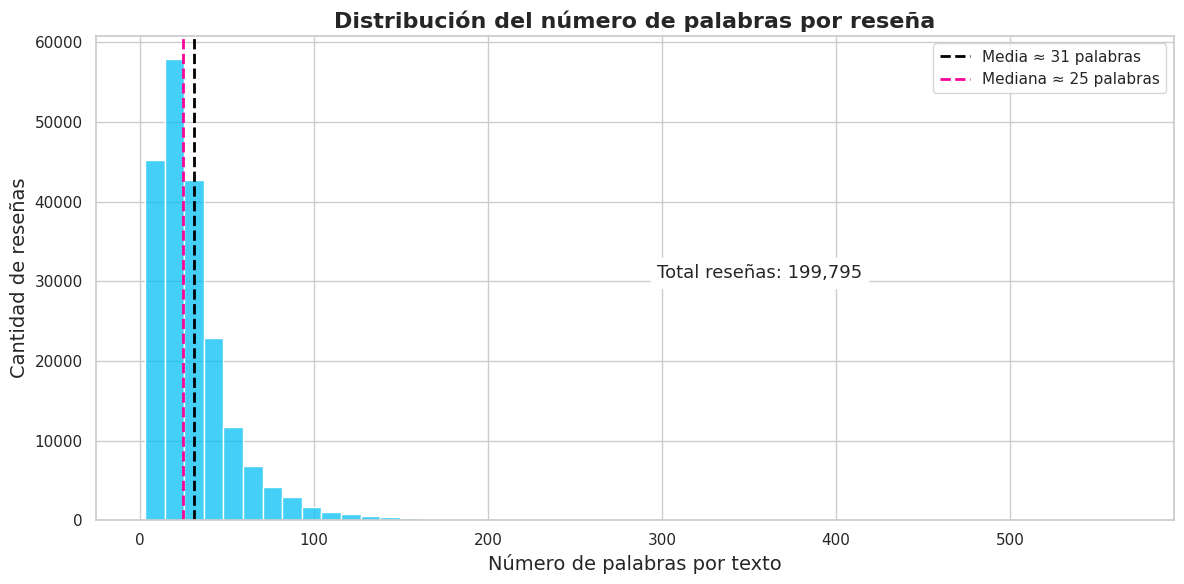

In [238]:
def distribucion_numero_palabras_por_reseña():
  plt.figure(figsize=(12, 6))

  sns.histplot(
      train_df['n_palabras'],
      bins = 50,
      color = color_primario
      )

  plt.title(
      "Distribución del número de palabras por reseña",
      fontsize = 16,
      fontweight = "bold"
  )

  plt.xlabel(
      "Número de palabras por texto",
      fontsize = 14
  )

  plt.ylabel(
      "Cantidad de reseñas",
      fontsize = 14
  )

  media = train_df['n_palabras'].mean()
  plt.axvline( # muestra la linea punteada que señala el promedio
      media,
      color = 'black',
      linestyle = "--",
      linewidth = 2,
      label = f"Media ≈ {media:.0f} palabras"
  )
  # Línea de referencia: mediana
  mediana = train_df['n_palabras'].median()
  plt.axvline(
      mediana,
      color=color_secundario,
      linestyle="--",
      linewidth=2,
      label=f"Mediana ≈ {mediana:.0f} palabras"
  )

  plt.text(
      0.50 * plt.xlim()[1],
      0.50 * plt.ylim()[1],
      f"Total reseñas: {len(train_df):,}",
      fontsize=13,
      bbox=dict(facecolor="white")
  )

  plt.legend() # Muestra la leyenda
  plt.tight_layout()
  plt.show()

distribucion_numero_palabras_por_reseña()

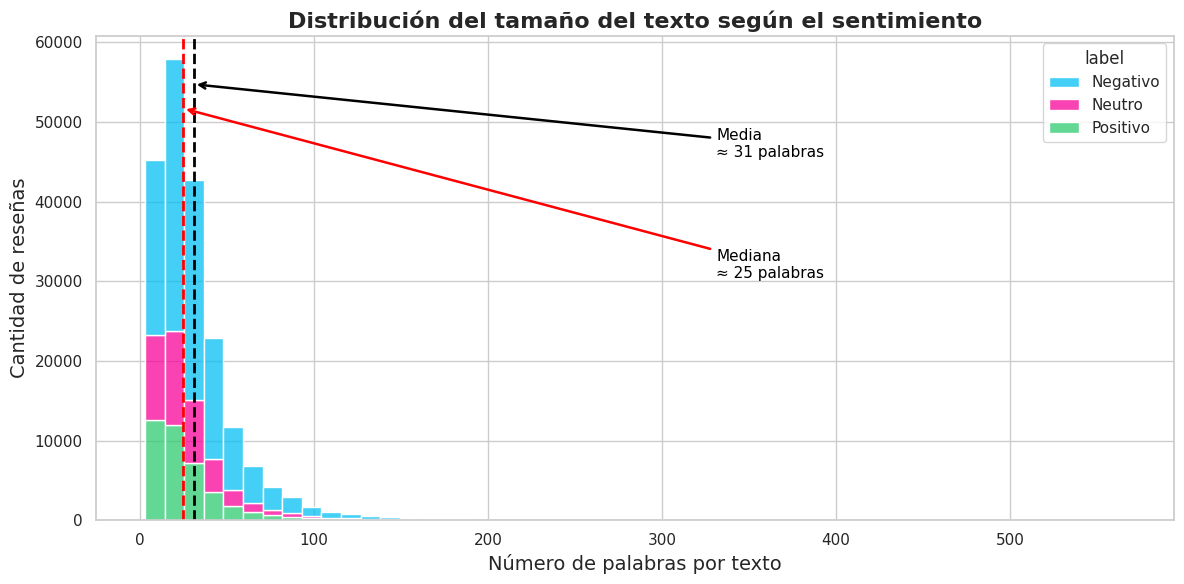

In [240]:
def distribucion_numero_palabras_por_reseña_por_sentimiento():
  fig, ax = plt.subplots(figsize=(12,6))

  sns.histplot(
      data = train_df,
      x = 'n_palabras',
      hue = 'label',
      palette = [color_primario, color_secundario, color_terciario],
      bins=50,
      multiple = "stack"
      )

  ax.set_title(
      "Distribución del tamaño del texto según el sentimiento",
      fontsize = 16,
      fontweight = "bold"
  )

  ax.set_xlabel(
      "Número de palabras por texto",
      fontsize = 14
  )

  ax.set_ylabel(
      "Cantidad de reseñas",
      fontsize = 14
  )

  media = train_df['n_palabras'].mean()
  ax.axvline( # muestra la linea punteada que señala el promedio
      media,
      color = 'black',
      linestyle = "--",
      linewidth = 2,
      label = f"Media ≈ {media:.0f} palabras"
  )
  # Línea de referencia: mediana
  mediana = train_df['n_palabras'].median()
  ax.axvline(
      mediana,
      color = 'red',
      linestyle = "--",
      linewidth = 2,
      label=f"Mediana ≈ {mediana:.0f} palabras"
  )

  ax.annotate(
      f"Media\n≈ {media:.0f} palabras",
      xy = (media, ax.get_ylim()[1] * 0.9),      # apunta a la línea
      xytext = (media + 300, ax.get_ylim()[1] * 0.75),
      arrowprops = dict(
            arrowstyle = "->",
            color = 'black',
            linewidth = 1.8
            ),
      fontsize = 11,
      color = 'black'
      )

  texto_moda = ('Mediana')
  ax.annotate(
      f"Mediana\n≈ {mediana:.0f} palabras",
        xy = (mediana, ax.get_ylim()[1] * 0.85),      # apunta a la línea
      xytext = (media + 300, ax.get_ylim()[1] * 0.50),
      arrowprops = dict(
            arrowstyle = "->",
            color = 'red',
            linewidth = 1.8
            ),
      fontsize = 11,
      color = 'black'
      )

  plt.tight_layout()
  plt.show()

distribucion_numero_palabras_por_reseña_por_sentimiento()

#### Boxplot

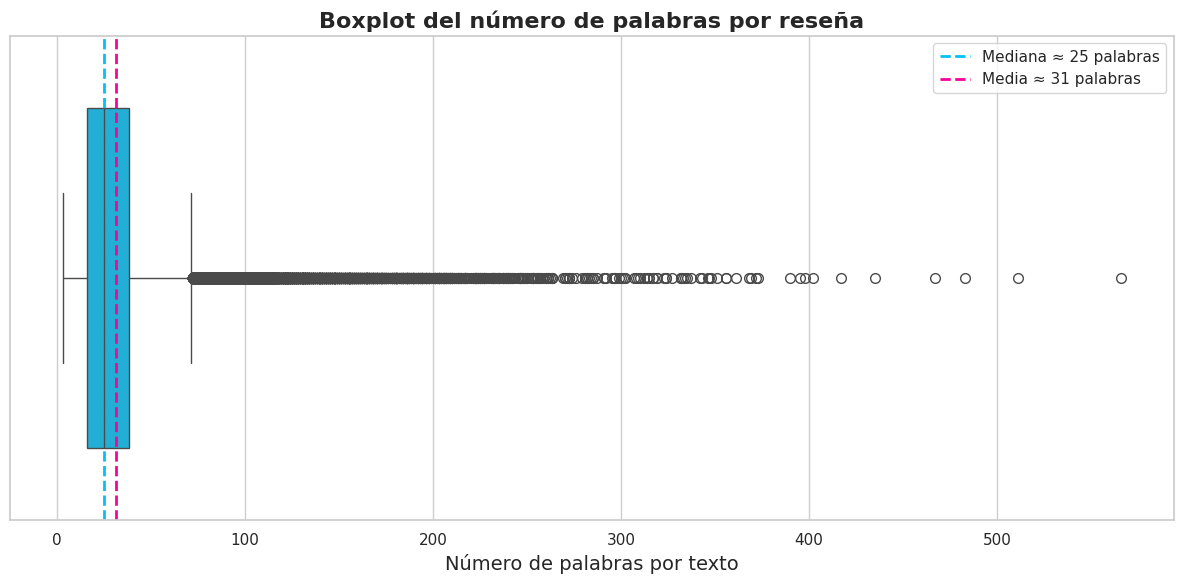

In [241]:
def boxplot_numero_palabras_por_reseña():
  plt.figure(figsize=(12, 6))

  sns.boxplot(
      x = train_df['n_palabras'],
      color = color_primario,
      width = 0.7, # Tamaño del boxplot
      fliersize = 7, # Tamaño de los puntos atípicos
  )

  plt.title(
      "Boxplot del número de palabras por reseña",
      fontsize = 16,
      fontweight = "bold"
  )

  plt.xlabel(
      "Número de palabras por texto",
      fontsize = 14
  )

  # Línea de referencia: mediana
  mediana = train_df['n_palabras'].median()
  plt.axvline(
      mediana,
      color=color_primario,
      linestyle="--",
      linewidth=2,
      label=f"Mediana ≈ {mediana:.0f} palabras"
  )
  # Línea de referencia: media
  media = train_df['n_palabras'].mean()
  plt.axvline(
      media,
      color=color_secundario,
      linestyle="--",
      linewidth=2,
      label=f"Media ≈ {media:.0f} palabras"
  )


  plt.legend()
  plt.tight_layout()
  plt.show()

boxplot_numero_palabras_por_reseña()

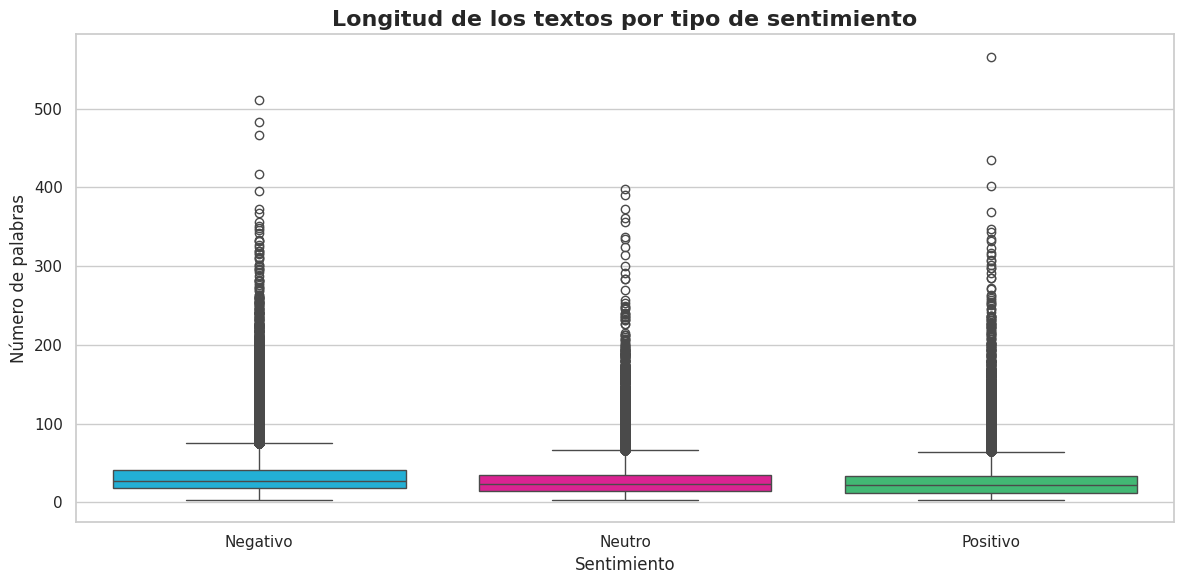

In [242]:
def boxplot_numero_palabras_por_reseña_por_sentimiento():
  plt.figure(figsize=(12,6))

  sns.boxplot(
      data = train_df,
      x='label',
      y = 'n_palabras',
      hue = 'label',
      palette = [color_primario, color_secundario, color_terciario]
  )

  plt.title(
      "Longitud de los textos por tipo de sentimiento",
      fontsize=16,
      fontweight="bold"
      )

  plt.xlabel("Sentimiento")

  plt.ylabel("Número de palabras")

  plt.tight_layout()
  plt.show()

boxplot_numero_palabras_por_reseña_por_sentimiento()

### **Conclusion**

#### **Conclusiones sobre la calidad de los datos**

- El conjunto de datos presenta una estructura clara y consistente, compuesta principalmente por dos columnas relevantes para el modelado: el texto de la reseña y su respectiva etiqueta de sentimiento. Tras el proceso de limpieza, se eliminaron 205 registros duplicados, una cantidad mínima en comparación con el tamaño total del conjunto de entrenamiento (casi 200 000 observaciones), lo que confirma una alta calidad inicial de los datos y reduce el riesgo de sesgos por repetición durante el entrenamiento del modelo.

- No se detectaron valores nulos en las columnas analizadas, y los tipos de datos son adecuados para tareas de procesamiento de lenguaje natural, permitiendo un flujo de trabajo eficiente sin transformaciones estructurales adicionales.

#### **Conclusiones sobre la distribucion de las clases**

- Las etiquetas originales basadas en calificaciones fueron mapeadas a tres clases de sentimiento: Negativo, Neutro y Positivo, permitiendo construir un enfoque multiclase alineado con los objetivos del proyecto.

- Las estadísticas descriptivas muestran una distribución equilibrada y consistente entre los conjuntos de entrenamiento, prueba y validación, con valores medios cercanos y rangos idénticos, lo que indica una correcta separación de los datos y una adecuada representatividad entre los subconjuntos.

#### **Conclucion sobre la longitud de los textos**

- El análisis de la longitud de las reseñas evidencia que la mayoría de los textos son relativamente cortos, con una media aproximada de 31 palabras y una mediana cercana a 25 palabras. La distribución presenta una asimetría positiva, generada por un número reducido de reseñas extensas que alcanzan hasta 566 palabras.

- El histograma muestra que las reseñas con sentimiento negativo tienden a ser más largas, mientras que los textos neutros y positivos se concentran principalmente en rangos bajos de longitud. Este comportamiento es consistente con patrones habituales en plataformas de comercio electrónico, donde los usuarios insatisfechos suelen elaborar comentarios más detallados.

#### **Conclusión general del EDA**

- El análisis exploratorio confirma que el conjunto de datos es adecuado para entrenar un modelo de análisis de sentimiento multiclase como el propuesto en el MVP. La calidad de los datos, la distribución coherente de las etiquetas y la longitud moderada de los textos favorecen el uso de técnicas como TF-IDF combinadas con modelos supervisados clásicos como Regresión Logística.

- Si bien existen valores extremos en la longitud de los textos, estos no comprometen el entrenamiento del modelo y pueden ser gestionados en etapas posteriores mediante técnicas de truncamiento o normalización. En conjunto, el EDA proporciona una base sólida para la construcción del modelo y permite identificar oportunidades claras de mejora para iteraciones futuras.

## <font color=#05C0F3>**Limpieza de datos**</font>

### **Tratamiento de Valores Nulos e Inconsistencias**

#### Conteo de valores nulos

In [ ]:
datos.isnull().sum()

,0
review_es,0
sentimiento,0
n_palabras,0


No hay valores nulos en ninguna columna

### **Limpieza y Normalización del Texto**

#### Eliminar reseñas en inglés

In [ ]:
def detectar_idioma(texto):
    try:
        return detect(texto) #Se usa la biblioteca langdetect
    except:
        return "desconocido"

In [ ]:
datos.shape

(49599, 3)

In [ ]:
#Columna con el idioma de la reseña (El procesamiento tardará)
datos['idioma_detectado'] = datos['review_es'].apply(detectar_idioma)

In [ ]:
datos_limpios = datos[datos['idioma_detectado'] == 'es'].copy() #Solo guarda los datos en español

In [ ]:
filas_originales = len(datos)
filas_limpias = len(datos_limpios)
print(f"Se eliminaron {filas_originales - filas_limpias} filas que no estaban en español")

Se eliminaron 1815 filas que no estaban en español


In [ ]:
datos = datos_limpios

In [ ]:
datos.shape

(47784, 4)

#### Verificar la distribución de la columna objetivo (Sentimiento)

In [ ]:
datos['sentimiento'].value_counts()

,count
sentimiento,
positivo,23935
negativo,23849


In [ ]:
print("\nEstadísticas de longitud antes del balanceo:")
print(datos.groupby('sentimiento')['n_palabras'].describe())


Estadísticas de longitud antes del balanceo:
               count        mean         std   min    25%    50%    75%    max
sentimiento                                                                   
negativo     23849.0  227.789090  157.364916   6.0  125.0  172.0  284.0  998.0
positivo     23935.0  230.686693  166.550784  10.0  122.0  170.0  290.0  955.0


#### Eliminar las reseñas más grandes (partes del sesgo) para mantener el equilibrio en el número de reseñas de ambos sentimientos

In [ ]:
datos_pos = datos[datos['sentimiento'] == 'positivo'].copy()
datos_neg = datos[datos['sentimiento'] == 'negativo'].copy()

In [ ]:
diferencia = len(datos_pos) - len(datos_neg)
print(f"Hay {diferencia} reseñas positivas extras")

Hay 86 reseñas positivas extras


In [ ]:
datos_pos_balanceado = datos_pos.sort_values(by='n_palabras', ascending=False).iloc[diferencia:]
len(datos_pos_balanceado)

23849

In [ ]:
datos_equilibrados = pd.concat([datos_pos_balanceado, datos_neg])

In [ ]:
datos = shuffle(datos_equilibrados, random_state=42).reset_index(drop=True)

In [ ]:
datos['sentimiento'].value_counts()

,count
sentimiento,
negativo,23849
positivo,23849


In [ ]:
print("\nEstadísticas de longitud tras el balanceo:")
print(datos.groupby('sentimiento')['n_palabras'].describe())


Estadísticas de longitud tras el balanceo:
               count        mean         std   min    25%    50%    75%    max
sentimiento                                                                   
negativo     23849.0  227.789090  157.364916   6.0  125.0  172.0  284.0  998.0
positivo     23849.0  228.243406  161.791663  10.0  121.0  169.0  289.0  883.0


#### Estandarización a minúsculas

In [ ]:
display(datos)

,review_es,sentimiento,n_palabras,idioma_detectado
0,Me derrota absolutamente por qué Godard se tom...,negativo,328,es
1,"¿Nunca debo ir a este hospital [o hospicio, si...",positivo,127,es
2,"Alan Rudolph es un director tan así, sin ese t...",negativo,233,es
3,Alquilé esto pensando que sería bastante bueno...,negativo,105,es
4,"La serie Azul Planet es, sin lugar a dudas, un...",positivo,209,es
...,...,...,...,...
47693,Crecí en la ciudad de Nueva York y todas las t...,positivo,179,es
47694,96 minutos de esto es cruel ... y amo a los an...,negativo,407,es
47695,"Oh hombre, ¿esta película alguna vez muerde!Si...",negativo,72,es
47696,"Sin duda, una de las grandes obras maestras de...",positivo,636,es


In [ ]:
datos['review_es_limpio'] = datos['review_es'].str.lower()

In [ ]:
datos['review_es_limpio']

,review_es_limpio
0,me derrota absolutamente por qué godard se tom...
1,"¿nunca debo ir a este hospital [o hospicio, si..."
2,"alan rudolph es un director tan así, sin ese t..."
3,alquilé esto pensando que sería bastante bueno...
4,"la serie azul planet es, sin lugar a dudas, un..."
...,...
47693,crecí en la ciudad de nueva york y todas las t...
47694,96 minutos de esto es cruel ... y amo a los an...
47695,"oh hombre, ¿esta película alguna vez muerde!si..."
47696,"sin duda, una de las grandes obras maestras de..."


#### Eliminación de caracteres especiales y números

Se usa regex (expresiones regulares) para remover símbolos, números o puntuación, lo cual es esencial para el procesamiento de texto

In [ ]:
datos['review_es_limpio'] = datos['review_es_limpio'].str.replace(r'[^a-záéíóúñü\s]', '', regex=True)

In [ ]:
display(datos['review_es_limpio'])

,review_es_limpio
0,me derrota absolutamente por qué godard se tom...
1,nunca debo ir a este hospital o hospicio si qu...
2,alan rudolph es un director tan así sin ese to...
3,alquilé esto pensando que sería bastante bueno...
4,la serie azul planet es sin lugar a dudas uno ...
...,...
47693,crecí en la ciudad de nueva york y todas las t...
47694,minutos de esto es cruel y amo a los antiguo...
47695,oh hombre esta película alguna vez muerdesi al...
47696,sin duda una de las grandes obras maestras de ...


`[^a-záéíóúñü\s]`

Significa:
  Cualquier carácter que NO sea:
  - letras minúsculas
  - letras con tilde
  - ñ, ü
  - espacios

#### Eliminar espacios múltiples

In [ ]:
datos['review_es_limpio'] = datos['review_es_limpio'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [ ]:
display(datos['review_es_limpio'])

,review_es_limpio
0,me derrota absolutamente por qué godard se tom...
1,nunca debo ir a este hospital o hospicio si qu...
2,alan rudolph es un director tan así sin ese to...
3,alquilé esto pensando que sería bastante bueno...
4,la serie azul planet es sin lugar a dudas uno ...
...,...
47693,crecí en la ciudad de nueva york y todas las t...
47694,minutos de esto es cruel y amo a los antiguos ...
47695,oh hombre esta película alguna vez muerdesi al...
47696,sin duda una de las grandes obras maestras de ...


## <font color=#05C0F3>**Transformación de Características (Feature Engineering)**</font>

In [ ]:
display(datos)

,review_es,sentimiento,n_palabras,idioma_detectado,review_es_limpio
0,Me derrota absolutamente por qué Godard se tom...,negativo,328,es,me derrota absolutamente por qué godard se tom...
1,"¿Nunca debo ir a este hospital [o hospicio, si...",positivo,127,es,nunca debo ir a este hospital o hospicio si qu...
2,"Alan Rudolph es un director tan así, sin ese t...",negativo,233,es,alan rudolph es un director tan así sin ese to...
3,Alquilé esto pensando que sería bastante bueno...,negativo,105,es,alquilé esto pensando que sería bastante bueno...
4,"La serie Azul Planet es, sin lugar a dudas, un...",positivo,209,es,la serie azul planet es sin lugar a dudas uno ...
...,...,...,...,...,...
47693,Crecí en la ciudad de Nueva York y todas las t...,positivo,179,es,crecí en la ciudad de nueva york y todas las t...
47694,96 minutos de esto es cruel ... y amo a los an...,negativo,407,es,minutos de esto es cruel y amo a los antiguos ...
47695,"Oh hombre, ¿esta película alguna vez muerde!Si...",negativo,72,es,oh hombre esta película alguna vez muerdesi al...
47696,"Sin duda, una de las grandes obras maestras de...",positivo,636,es,sin duda una de las grandes obras maestras de ...


### **Definición de variables de entrada (X) y salida (y)**

In [ ]:
X = datos['review_es_limpio']

In [ ]:
display(X)

,review_es_limpio
0,me derrota absolutamente por qué godard se tom...
1,nunca debo ir a este hospital o hospicio si qu...
2,alan rudolph es un director tan así sin ese to...
3,alquilé esto pensando que sería bastante bueno...
4,la serie azul planet es sin lugar a dudas uno ...
...,...
47693,crecí en la ciudad de nueva york y todas las t...
47694,minutos de esto es cruel y amo a los antiguos ...
47695,oh hombre esta película alguna vez muerdesi al...
47696,sin duda una de las grandes obras maestras de ...


In [ ]:
y = datos['sentimiento'].map({
    'negativo': 0,
    'positivo': 1
})

In [ ]:
display(y)

,sentimiento
0,0
1,1
2,0
3,0
4,1
...,...
47693,1
47694,0
47695,0
47696,1


### **División de datos en conjuntos de entrenamiento y prueba**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### **Inicialización del Vectorizador TF-IDF**

El TF-IDF (Term Frequency-Inverse Document Frequency) es la técnica clave que transforma el texto en números, mostrando qué palabras son más importantes para cada documento/reseña.

In [ ]:
stopwords_es = stopwords.words('spanish')

In [ ]:
vectorizador = TfidfVectorizer(
    stop_words = stopwords_es,
    ngram_range = (1, 2),
    max_features = 5000,
    min_df = 5,
    max_df = 0.9
)

### **Ajuste (fit) y Transformación (transform) del conjunto de entrenamiento**

In [ ]:
X_train_tfidf  = vectorizador.fit_transform(X_train)

In [ ]:
display(X_train_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2525164 stored elements and shape (33388, 5000)>

### **Transformación del conjunto de prueba**

In [ ]:
X_test_tfidf = vectorizador.transform(X_test)

In [ ]:
display(X_test_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1079896 stored elements and shape (14310, 5000)>

#### Dimension

In [ ]:
X_train_tfidf.shape

(33388, 5000)

In [ ]:
X_test_tfidf.shape

(14310, 5000)

## <font color=#05C0F3>**Modelado y Evaluación**</font>

El modelo recomendado es la Regresión Logística, una técnica de clasificación supervisada simple y efectiva para este tipo de problemas.

### **Entrenamiento**

#### Inicialización del modelo de clasificación (Regresión Logística)

In [ ]:
modelo = LogisticRegression(random_state=42)

#### Entrenamiento del modelo

In [ ]:
modelo.fit(X_train_tfidf, y_train, )

LogisticRegression(random_state=42)

#### Predicciones

In [ ]:
y_pred = modelo.predict(X_test_tfidf)

In [ ]:
y_proba = modelo.predict_proba(X_test_tfidf) # Obtiene las probabilidades, esencial para el contrato de la API

### **Evaluación del Desempeño**

#### Cálculo y presentación de métricas

In [ ]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=['negativo', 'positivo']))


Reporte de clasificación:
              precision    recall  f1-score   support

    negativo       0.88      0.86      0.87      7170
    positivo       0.86      0.88      0.87      7140

    accuracy                           0.87     14310
   macro avg       0.87      0.87      0.87     14310
weighted avg       0.87      0.87      0.87     14310



#### Obtener palabras más significativas para cada sentimiento

In [ ]:
palabras = vectorizador.get_feature_names_out()
coefs = modelo.coef_.flatten()
datos_palabras = pd.DataFrame({'palabra': palabras, 'coeficiente': coefs})

In [ ]:
top_pos = datos_palabras.nlargest(10, 'coeficiente')
top_neg = datos_palabras.nsmallest(10, 'coeficiente')
top_palabras = pd.concat([top_pos, top_neg])

/tmp/ipython-input-3743336128.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_palabras, x='coeficiente', y='palabra', palette='coolwarm')


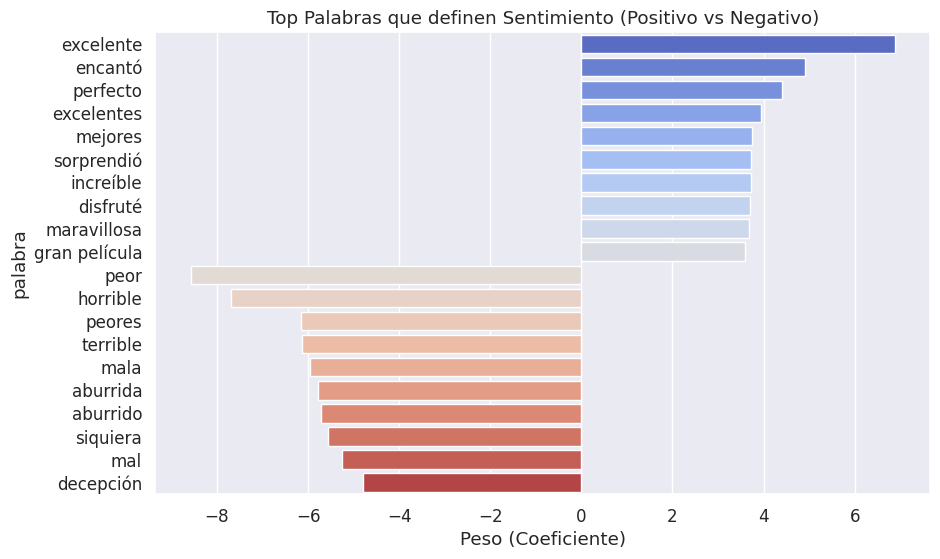

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_palabras, x='coeficiente', y='palabra', palette='coolwarm')
plt.title('Top Palabras que definen Sentimiento (Positivo vs Negativo)')
plt.xlabel('Peso (Coeficiente)')
plt.show()

#### Análisis de Errores


In [ ]:
datos_test = X_test.to_frame(name='review').copy()
datos_test['real'] = y_test
datos_test['prediccion'] = y_pred

In [ ]:
errores = datos_test[datos_test['real'] != datos_test['prediccion']]
print(f"Total de errores: {len(errores)} de {len(datos_test)}")

Total de errores: 1890 de 14310


In [ ]:
errores.sample(10)

,review,real,prediccion
1912,la leyenda de dragoon es uno de esos juegos po...,1,0
41767,vi el messiah hace unos meses y no pudimos ver...,1,0
11852,fue genial ver algunas de mis estrellas favori...,0,1
4047,el problema con otros actores fundidos en el r...,1,0
24654,la película la puerta del cielo fue una buena ...,0,1
25296,en las montañas de japón el joven artista de s...,0,1
15999,el agua muestra la difícil situación de las vi...,0,1
41138,no voy a decir la historia de la película como...,0,1
14971,entonces qué constituye una verdadera película...,1,0
4108,como parte de la celebración del lanzamiento d...,1,0


##### Falsos Positivos (Eran negativos y se clasificaron como positivos)

Son los errores más importantes y que se tienen que destacar, dado que en los requisitos (y en general para cualquier modelo de atención al cliente) es peor ignorar los comentarios negativos y no darles atención (falsos positivos)

In [ ]:
for i, row in errores[errores['prediccion'] == 1].head(3).iterrows():
    print(f"Review: {row['review'][:300]}...")
    print(f"Real: {row['real']} | Pred: {row['prediccion']}\n")

Review: todavía tengo que leer una revisión profesional negativa de esta películasupongo que debo haber perdido algoel comienzo es intrigante los tres personajes principales se reúnen a altas horas de la noche en una barra de otro modo vacía y entre sí con historias inventadasesa es la mejor partedespués de...
Real: 0 | Pred: 1

Review: otra película que hace peor la historia de los chicos de la playa de lo que esrecuerdo especialmente la escena cuando brian dice que es para dejar de fumar y los otros niños lo llaman traidorno sucedí así y al igual que la película indica al principio es que algunas escenas se requieren sobrepasadas...
Real: 0 | Pred: 1

Review: esta película es sobre una brecha que existe entre el mundo real y el mundo de los muertos hay un montón de mumbojumbo sobre internet es decir si instala un programa en la computadora se ve a la gente muerta al igual que si juega una cinta de video morirá en ringu francamente la mayoría de esto pare...
Real: 0 | Pred: 1



##### Falsos Negativos (Eran positivos y se clasificaron como negativos)

In [ ]:
for i, row in errores[errores['prediccion'] == 0].head(3).iterrows():
    print(f"Review: {row['review'][:300]}...")
    print(f"Real: {row['real']} | Pred: {row['prediccion']}\n")

Review: esto no es una película seria y no pretende ser pero no es tan malo como algunas de sus críticas su título y los primeros diez minutos le llevan a esperar la parcela es muy tonta pero esto se suma a ladiversión y entusiasmo alegre que corre por la películalos personajes se desempeñan con simpatía y ...
Real: 1 | Pred: 0

Review: oceans if you robes cincuenta millones de dólares te encontrarán alan rickman como hans gruber muere duro este adagio ciertamente suena verdadero en esta secuela terry benedicto ha sido informado de que danny ocean y sus compadres fueron los que lo derribaron y ahora lo quiere de nuevo la pandilla d...
Real: 1 | Pred: 0

Review: por alguna razón siempre disfruto de las películas que las personas odian cuando realmente no creo que sean tan malas y esta es una de esas películas en el caso de esta película creo que es demasiado criticado demasiado realmente no es tan malo de una película en absoluto de hecho creo que esta es u...
Real: 1 | Pred: 0



#### Matriz de confusión


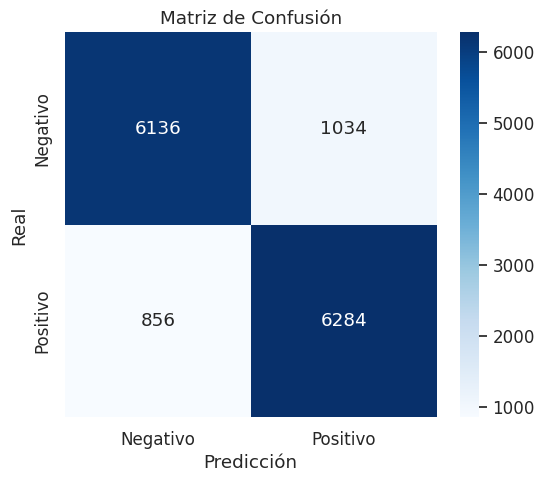

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.title('Matriz de Confusión')
plt.show()

La matriz de confusión muestra como hay un poco más de falsos positivos que de falsos negativos, para este ejemplo, nos importa mucho más las reseñas negativas para poder atender el disgusto de los clientes. Por lo tanto, es preferible tener menos falsos positivos (reseñas negativas tomadas como positivas) aunque eso conlleve a tener un poco más de falsos negativos.

#### Obtener el mejor umbral para reducir falsos positivos

In [ ]:
pipeline_test = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words=stopwords_es,
        ngram_range=(1, 2),
        max_features=5000,
        min_df=5,
        max_df=0.9
    )),
    ('clf', LogisticRegression(random_state=42))
])

pipeline_test.fit(X, y)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.9, max_features=5000, min_df=5,
                                 ngram_range=(1, 2),
                                 stop_words=['de', 'la', 'que', 'el', 'en', 'y',
                                             'a', 'los', 'del', 'se', 'las',
                                             'por', 'un', 'para', 'con', 'no',
                                             'una', 'su', 'al', 'lo', 'como',
                                             'más', 'pero', 'sus', 'le', 'ya',
                                             'o', 'este', 'sí', 'porque', ...])),
                ('clf', LogisticRegression(random_state=42))])

In [ ]:
probs = pipeline_test.predict_proba(X_test)[:, 1]

In [ ]:
def probar_umbral(umbral):
    # Si la probabilidad es mayor al umbral, es 'positivo', si no 'negativo'
    preds_ajustadas = np.where(probs > umbral, 1, 0)

    # Generar matriz de confusión con el nuevo umbral
    cm = confusion_matrix(y_test, preds_ajustadas, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    return fp, fn, cm

In [ ]:
umbrales = [0.5, 0.6, 0.63, 0.64, 0.645, 0.65, 0.655, 0.66, 0.67, 0.7, 0.8]

In [ ]:
print(f"{'Umbral':<10} {'Falsos Positivos (Riesgo)':<25} {'Falsos Negativos (Revisión extra)'}")
print("-" * 70)
for u in umbrales:
    fp, fn, _ = probar_umbral(u)
    print(f"{u:<10} {fp:<25} {fn}")

Umbral     Falsos Positivos (Riesgo) Falsos Negativos (Revisión extra)
----------------------------------------------------------------------
0.5        843                       675
0.6        527                       1080
0.63       451                       1251
0.64       415                       1300
0.645      399                       1331
0.65       381                       1358
0.655      372                       1387
0.66       360                       1414
0.67       336                       1489
0.7        273                       1695
0.8        127                       2629


#### Usando el mejor umbral

Al tener un umbral más alto, es más estricto para que el modelo clasifique una reseña como positiva, lo que reduce significativamente la probabilidad de no atender una reseña negativa.

El mejor umbral fue de ***0.65***, con lo que se reducen la cantidad de falsos positivos, pero sin llevar a una enorme cantidad de falsos negativos.
Considerando los requisitos del proyecto, es priorizable detectar correctamente las reseñas negativas que las positivas.

In [ ]:
mejor_umbral = 0.65
y_pred_final = np.where(probs > mejor_umbral, 1, 0)


--- Matriz de Confusión con Umbral 0.65 ---


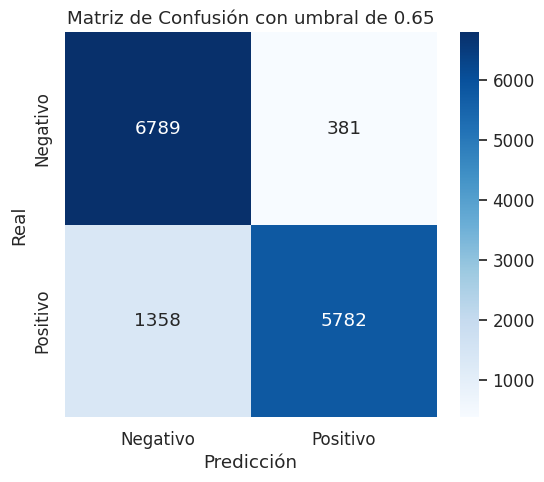

In [ ]:
print(f"\n--- Matriz de Confusión con Umbral {mejor_umbral} ---")
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.title('Matriz de Confusión con umbral de 0.65')
plt.show()

## <font color=#05C0F3>**Serialización e Integración con Back-End (Java)**</font>

Esta es la fase de entrega del artefacto. El modelo entrenado y, crucialmente, el vectorizador TF-IDF (necesario para transformar el texto de entrada que envía el BE), deben ser guardados en un formato binario (joblib o pickle)

### **Definición del Pipeline de Predicción**

Para garantizar que el Back-End pueda hacer predicciones correctas, es mejor serializar el Pipeline completo: Vectorizador + Modelo.

In [ ]:
pipeline_final = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words=stopwords_es,
        ngram_range=(1, 2),
        max_features=5000,
        min_df=5,
        max_df=0.9
    )),
    ('clf', LogisticRegression(random_state=42))
])

### **Reentrenar el pipeline con X y Y**

In [ ]:
pipeline_final.fit(X, y)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.9, max_features=5000, min_df=5,
                                 ngram_range=(1, 2),
                                 stop_words=['de', 'la', 'que', 'el', 'en', 'y',
                                             'a', 'los', 'del', 'se', 'las',
                                             'por', 'un', 'para', 'con', 'no',
                                             'una', 'su', 'al', 'lo', 'como',
                                             'más', 'pero', 'sus', 'le', 'ya',
                                             'o', 'este', 'sí', 'porque', ...])),
                ('clf', LogisticRegression(random_state=42))])

### **Serialización**

In [ ]:
joblib.dump(pipeline_final, 'sentiment_model_1.2.joblib')

['sentiment_model_1.2.joblib']

### **Contrato de Integración y Pruebas Locales**

Prueba en Python para simular la predicción, mostrando cómo el modelo toma un texto sin procesar y genera una predicción con probabilidad.

In [ ]:
# Simulación de predicción
texto_ejemplo = "La interfaz es confusa y me hicieron esperar mucho."

In [ ]:
pred_sentimiento = pipeline_final.predict([texto_ejemplo])

In [ ]:
probabilidades = pipeline_final.predict_proba([texto_ejemplo])

In [ ]:
# Sentimiento y su probabilidad asociada (máxima probabilidad)
max_proba = np.max(probabilidades)

In [ ]:
print(f"Predicción: {pred_sentimiento}, Probabilidad: {max_proba:.2f}")

Predicción: [0], Probabilidad: 0.63


#### **FastAPI**

**El siguiente codigo es de prueba y va en el archivo del proyecto en github**

~~~
# Instalaciones
# pip install fastapi uvicorn joblib scikit-learn nltk # Se ejecuta en consola

# app.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib
import numpy as np

# Cargar el modelo (UNA SOLA VEZ)
app = FastAPI(title="Sentiment Analysis API")

modelo = joblib.load("sentiment_model_1.1.joblib")

# Contrato de entrada (request)
class SentimentRequest(BaseModel):
    text: str
#    {
#        text: "La película fue excelente"
#    }

# Contrato de salida (response)
class SentimentResponse(BaseModel):
    prevision: str
    probabilidad: float

# Endpoint principal /sentiment
@app.post("/sentiment", response_model=SentimentResponse)
def predict_sentiment(request: SentimentRequest):

    texto = request.text.strip()

    if len(texto) < 10:
        raise HTTPException(
            status_code=400,
            detail="El texto es demasiado corto para analizar sentimiento"
        )

    pred = modelo.predict([texto])[0]
    proba = modelo.predict_proba([texto])[0]

    probabilidad_max = float(np.max(proba))

    sentimiento = "Positivo" if pred == 1 else "Negativo"

    return {
        "prevision": sentimiento,
        "probabilidad": round(probabilidad_max, 3)
    }

# Ejecutar el servidor
# uvicorn app:app --reload # Se ejecuta en consola

POST http://localhost:8000/sentiment
Content-Type: application/json
# Eso va en:
# Postman
# Swagger
# README
# documentación

# Formato
{
  "text": "La interfaz es confusa y lenta"
}
{
  "prevision": "Negativo",
  "probabilidad": 0.92
}

~~~

**Comentario Fast API (Prueba)** **NO EJECUTAR**

**El archivo de Git tendría que tener esta estrucura**

- Modelo_hackathon.ipynb
- app.py
- requirements.txt
- sentiment_model.joblib

### Archivo requirements.txt
### Dentro del archivo .txt el siguiente texto:

- fastapi
- uvicorn
- joblib
- scikit-learn
- nltk
- numpy

**Cómo ejecutarlo (Terminal)**

**CMD, Terminal o PowerShell**

- 1. Instalar las librerías (solo la primera vez): pip install -r requirements.txt
- 2. Encender el servidor: uvicorn app:app --reload

### Arhivo ipynb, Modelo_hackathon.ipynb
El archivo .ipynb crea el archivo (sentiment_model.joblib)
Descargar el archivo .joblib y colocarlo dentro de la estructura del Git

**Cómo ejecutarlo (Terminal)**

**CMD, Terminal o PowerShell**

- 1. Instalar las librerías (solo la primera vez): `pip install -r requirements.txt`
- 2. Encender el servidor: `uvicorn app:app --reload`